# 2 · Forward models $\mathbf{A} = \mathbf{\overline{W}}\mathbf{Y}$
Companion notebook to *Fast reconstruction of tensor tomographic X-ray scattering data for real-time applications*
(Antunes, Pelt & Batenburg, Optics Express, [doi:10.1364/OE.597352](https://doi.org/10.1364/OE.597352)).

The forward model (Eq. 1) splits into mumott's tensor-compatible tomographic projector $\mathbf{\overline{W}}$ and a
view-dependent mixing operator $\mathbf{Y}$. Here we build $\mathbf{Y}$ for the three representations of notebook 01 and simulate
their projections. Run notebook 01 first.

In [1]:
# Colab only: fetch the repository and install mumott (skipped everywhere else)
import os, sys
if 'google.colab' in sys.modules and not os.getcwd().endswith('notebooks'):
    !git clone -q https://github.com/mesqant/algebraic-filters-tt
    %pip install -q mumott==2.1 "scipy<1.17" colorcet
    %cd algebraic-filters-tt/notebooks

In [2]:
# Imports (mumott's INFO logging is silenced)
import logging
import warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import colorcet  # registers the 'cet_*' colormaps
logging.getLogger('mumott').setLevel(logging.WARNING)
from mumott.data_handling import DataContainer
from mumott.methods.basis_sets import SphericalHarmonics
from mumott.methods.projectors import SAXSProjector, SAXSProjectorCUDA

In [3]:
# Compute backend: GPU (cupy + mumott's CUDA projector) if available, else CPU (numpy + mumott's numba projector)
try:
    import cupy as cp
    gpu_available = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    gpu_available = False
xp = cp if gpu_available else np
to_numpy = cp.asnumpy if gpu_available else np.asarray  # device → host copy (no-op on CPU)
# Paper-size run with all 417 views; small_run = True uses every 4th view (~4× faster, results differ from the paper)
small_run = False
view_step = 4 if small_run else 1
f'GPU: {gpu_available}, small run: {small_run}, view step: {view_step}'

'GPU: True, small run: False, view step: 1'

In [4]:
# Build the first notebook's outputs if they are missing (e.g. on a fresh Colab runtime)
data_dir = Path('../data')
if not (data_dir / 'phantom_representations.npz').exists():
    !jupyter nbconvert --to notebook --execute 01_representations.ipynb --output-dir /tmp

In [5]:
# Load the three representations of the phantom from notebook 01
phantom = np.load(data_dir / 'phantom_representations.npz')
volume_shape = phantom['tensor'].shape[:3]
{name: phantom[name].shape for name in ['spherical', 'directional', 'tensor']}

{'spherical': (57, 57, 57, 28),
 'directional': (57, 57, 57, 7),
 'tensor': (57, 57, 57, 6)}

## Tomographic projector $\mathbf{\overline{W}}$

In [6]:
# Acquisition geometry of the simulated 'M' dataset (417 views, tilts 0–45°), resized to the padded volume
with warnings.catch_warnings(record=True):  # mumott's deprecation warnings would re-enable all others
    geometry = DataContainer(str(data_dir / 'M_sim_1.0e+01.h5')).geometry
geometry.volume_shape = volume_shape
geometry.projection_shape = volume_shape[:2]
len(geometry)

417

In [7]:
# Keep every view_step-th view (no-op for the full-size run)
for view in reversed(range(len(geometry))):
    if view % view_step:
        del geometry[view]
inner_angles, outer_angles = np.asarray(geometry.inner_angles), np.asarray(geometry.outer_angles)
len(geometry)

417

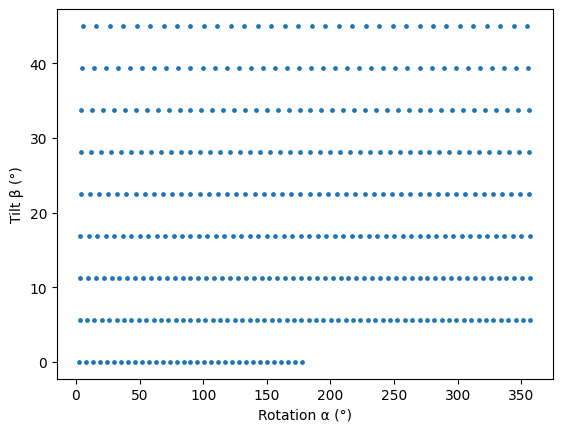

In [8]:
# Show the sampled rotation and tilt angles
plt.scatter(np.degrees(inner_angles), np.degrees(outer_angles), s=6)
plt.xlabel('Rotation α (°)')
plt.ylabel('Tilt β (°)');

In [9]:
# mumott's tensor-compatible projector: projects every tensor component independently
projector = SAXSProjectorCUDA(geometry) if gpu_available else SAXSProjector(geometry)
projector

Field,Size,Data
is_dirty,1,False
hash,17,d6c2b8


In [10]:
# Forward model A = W̄Y and its adjoint Aᵀ = YᵀW̄ᵀ, for a mixing operator Y of shape (views, S channels, C components)
def to_projector(array):  # mumott projectors take host arrays (float32 for CUDA, float64 for CPU)
    return np.asarray(to_numpy(array), dtype=projector.dtype)

def forward(volume, mixing):
    projections = xp.asarray(projector.forward(to_projector(volume)), dtype=xp.float32)
    return xp.einsum('vijc,vsc->vijs', projections, mixing)

def backward(projections, mixing):
    unmixed = xp.einsum('vijs,vsc->vijc', projections, mixing)
    return xp.asarray(projector.adjoint(to_projector(unmixed)), dtype=xp.float32)

## Mixing operator $\mathbf{Y}$: spherical harmonics (SASTT, Nielsen et al.)

In [11]:
# Y for the SH representation, taken directly from mumott's basis set for the probed reciprocal-space coordinates
max_ell = int(phantom['max_ell'])
basis_set = SphericalHarmonics(ell_max=max_ell, probed_coordinates=geometry.probed_coordinates)
mixing_spherical = xp.asarray(basis_set.projection_matrix, dtype=xp.float32)
mixing_spherical.shape

(417, 8, 28)

## Mixing operator $\mathbf{Y}$: directional (GITT, Kim et al., Eq. 3 of [doi:10.1103/PhysRevApplied.18.014043](https://doi.org/10.1103/PhysRevApplied.18.014043))

In [12]:
# Beam direction for a rotation α and tilt β
def beam_direction(alpha, beta):
    polar = np.pi / 2 - beta
    return np.array([np.sin(polar) * np.cos(alpha), np.sin(polar) * np.sin(alpha), np.cos(polar)], dtype=np.float32)

In [13]:
# Orthonormal basis (e1, e2) of the detector plane perpendicular to the beam u
def normalize(v):
    return (v / np.maximum(np.linalg.norm(v, axis=-1, keepdims=True), 1e-12)).astype(np.float32)

def detector_plane_basis(u):
    u = normalize(u)
    reference = np.array([0, 0, 1], dtype=np.float32) if abs(u[2]) < 0.9 else np.array([0, 1, 0], dtype=np.float32)
    e1 = normalize(np.cross(u, reference))
    e2 = normalize(np.cross(-u, e1))
    return e1, e2

In [14]:
# Weights (S channels × 7 directions) for one view: (g_s·d)² |u × d|², with g_s the S sensitivity directions in the detector plane
n_channels_directional = 8

def directional_weights(u, directions, n_channels=n_channels_directional):
    e1, e2 = detector_plane_basis(u)
    channel_angles = np.linspace(0, np.pi, n_channels, endpoint=False, dtype=np.float32)
    g = normalize(np.cos(channel_angles)[:, None] * e1 + np.sin(channel_angles)[:, None] * e2)
    d = normalize(np.asarray(directions, dtype=np.float32))
    cross_squared = 1 - (d @ normalize(u)) ** 2  # |u × d|² = 1 − (u·d)² for unit vectors
    return (g @ d.T) ** 2 * cross_squared[None, :]

In [15]:
# Y for the directional representation, stacked over all views
mixing_directional = np.stack([directional_weights(beam_direction(a, b), phantom['directions'])
                               for a, b in zip(inner_angles, outer_angles)])
mixing_directional = xp.asarray(mixing_directional, dtype=xp.float32)
mixing_directional.shape

(417, 8, 7)

## Mixing operator $\mathbf{Y}$: rank-2 tensor (SBTT/GITT, Lautizi et al., [doi:10.1103/PhysRevApplied.22.024031](https://doi.org/10.1103/PhysRevApplied.22.024031))

In [16]:
# Weights (3 × 6) for one view: marginalise the 3D covariance T onto the detector plane, EᵀTE with E = [e1 e2],
# keeping the unique 2D entries (11, 22, 12) and the unique 3D entries (11, 22, 33, 12, 13, 23)
entries_2d = [(0, 0), (1, 1), (0, 1)]
entries_3d = [(0, 0), (1, 1), (2, 2), (0, 1), (0, 2), (1, 2)]

def tensor_weights(u):
    E = np.column_stack(detector_plane_basis(u))  # (3, 2)
    weights = np.zeros((len(entries_2d), len(entries_3d)), dtype=np.float32)
    for s, (p, q) in enumerate(entries_2d):
        for c, (a, b) in enumerate(entries_3d):
            weights[s, c] = E[a, p] * E[b, q] + (E[b, p] * E[a, q] if a != b else 0)  # off-diagonals appear twice
    return weights

In [17]:
# Y for the tensor representation, stacked over all views
mixing_tensor = np.stack([tensor_weights(beam_direction(a, b)) for a, b in zip(inner_angles, outer_angles)])
mixing_tensor = xp.asarray(mixing_tensor, dtype=xp.float32)
mixing_tensor.shape

(417, 3, 6)

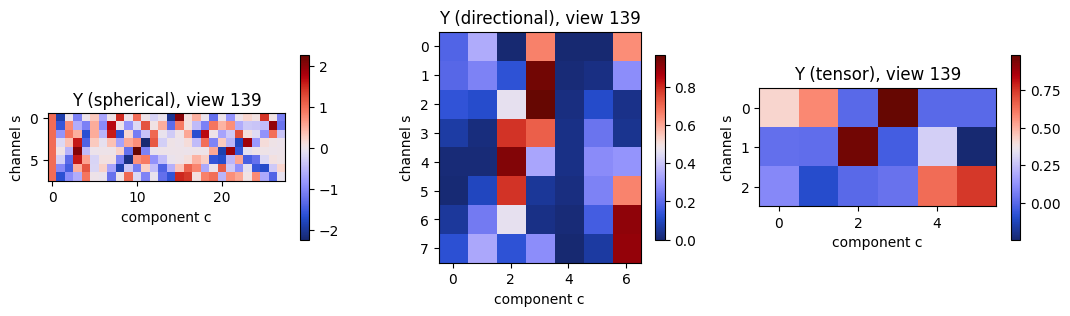

In [18]:
# Show Y for a single view for each representation (rows: detector channels s, columns: tensor components c)
mixing = {'spherical': mixing_spherical, 'directional': mixing_directional, 'tensor': mixing_tensor}
view = len(geometry) // 3
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, (name, Y) in zip(axes, mixing.items()):
    im = ax.imshow(to_numpy(Y[view]), cmap='cet_CET_D1A')
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set(title=f'Y ({name}), view {view}', xlabel='component c', ylabel='channel s')

## Simulated projections $\mathbf{b} = \mathbf{A}\mathbf{x}$

In [19]:
# Project each representation with its own mixing operator
projections = {name: forward(phantom[name], Y) for name, Y in mixing.items()}
{name: b.shape for name, b in projections.items()}

{'spherical': (417, 57, 57, 8),
 'directional': (417, 57, 57, 8),
 'tensor': (417, 57, 57, 3)}

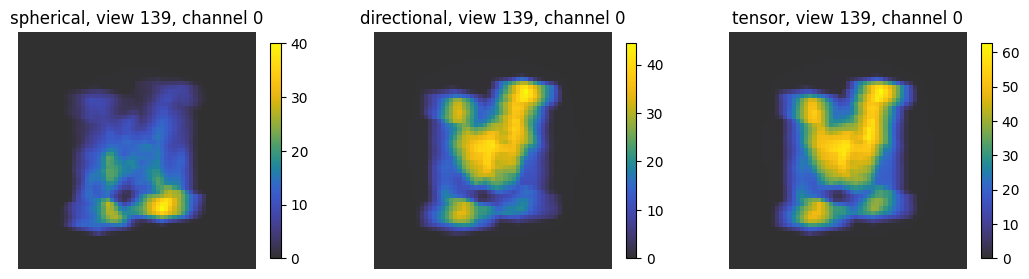

In [20]:
# Show the first detector channel of one view for each representation
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, b) in zip(axes, projections.items()):
    im = ax.imshow(to_numpy(b[view, ..., 0]).T, cmap='cet_gouldian', origin='lower')
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'{name}, view {view}, channel 0')
    ax.axis('off')

In [21]:
# Check the adjoint: ⟨Ax, y⟩ ≈ ⟨x, Aᵀy⟩ for random x, y (mumott's projector/back-projector pair is matched to within ~1%)
for name, Y in mixing.items():
    x = xp.random.rand(*volume_shape, Y.shape[2]).astype(xp.float32)
    y = xp.random.rand(*projections[name].shape).astype(xp.float32)
    print(f'{name:12s} ⟨Ax,y⟩ / ⟨x,Aᵀy⟩ = {float(xp.vdot(forward(x, Y), y) / xp.vdot(x, backward(y, Y))):.5f}')

spherical    ⟨Ax,y⟩ / ⟨x,Aᵀy⟩ = 1.00437


directional  ⟨Ax,y⟩ / ⟨x,Aᵀy⟩ = 1.00499


tensor       ⟨Ax,y⟩ / ⟨x,Aᵀy⟩ = 1.00512


In [22]:
# Cache the mixing operators and the (subsampled) geometry for notebook 03
np.savez(data_dir / 'mixing_operators.npz', view_step=view_step,
         **{name: to_numpy(Y) for name, Y in mixing.items()})
geometry.write(str(data_dir / 'geometry.geo'))
sorted(data_dir.iterdir())

[PosixPath('../data/.gitkeep'),
 PosixPath('../data/M_sim_1.0e+01.h5'),
 PosixPath('../data/algebraic_filters_directional_50iter_417views.npy'),
 PosixPath('../data/algebraic_filters_spherical_50iter_417views.npy'),
 PosixPath('../data/algebraic_filters_tensor_50iter_417views.npy'),
 PosixPath('../data/geometry.geo'),
 PosixPath('../data/mixing_operators.npz'),
 PosixPath('../data/phantom_representations.npz'),
 PosixPath('../data/runtimes.npz')]

Next: [notebook 03](03_algebraic_filters.ipynb).